In [1]:
## aart_func is a file with the functions for the image generation
from aart_func import *
## params have all the important params of the simulation
from params import *
plt.rcParams['text.usetex'] = True


Thanks for using AART
Copyright (C) 2023, A. Cardenas-Avendano, H. Zhu & A. Lupsasca



In [2]:
# local paths for loading data and downloading images
path_lensingband17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5"
path_lensingband60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i60_dx0.1.h5"

path_raytracing17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5"
path_raytracing60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i60_dx0.1.h5"

path_images = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\Imagenes"

# Histogram for $n=0$, with $ \theta_o = 17^\circ$ and  $ \theta_o = 60^\circ$

In [87]:
# Lensing bands params importation for i = 17
fnbands = path_lensingband17
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
N17_live0 = mask0.sum() 
lim0=int(h5f["lim0"][0])

h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5


In [89]:
# Ray tracing params importation for i = 17
fnrays = path_raytracing17
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

h5f.close()

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5


In [91]:
#time renormalizartion 
t_renorm_17 = t0 + (D_obs + 2*np.log(D_obs))
alpha17 = supergrid0[:, 0]
beta17 = supergrid0[:, 1]

valid_mask = np.isfinite(t_renorm_17)
alpha17 = alpha17[valid_mask]
beta17 = beta17[valid_mask]
t_renorm_17 = t_renorm_17[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin17, Tmax17 = np.percentile(t_renorm_17, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_17),np.max(t_renorm_17))
print("filtered range of coordinates",Tmin17,Tmax17)

# Create a mask for the values within the range 
mask_in_range_17 = (t_renorm_17 >= Tmin17) & (t_renorm_17 <= Tmax17 )

#data filtering 
t_renorm_17 = t_renorm_17[mask_in_range_17]
alpha17 = alpha17[mask_in_range_17]
beta17 = beta17[mask_in_range_17]

original range of coordinates -35.667235246168275 14.249619164365868
filtered range of coordinates -35.667235246168275 14.138239200566256


In [93]:
# Lensing bands params importation for i = 60
fnbands = path_lensingband60
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
N60_live0 = mask0.sum() 
lim0=int(h5f["lim0"][0])


h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i60_dx0.1.h5


In [95]:
# Ray tracing params importation for i = 60
fnrays = path_raytracing60
#Imprimimos la dirección donde se encuentran
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i60_dx0.1.h5


In [97]:
#time renormalizartion 
t_renorm_60 = t0 + (D_obs + 2*np.log(D_obs))
alpha60 = supergrid0[:, 0]
beta60 = supergrid0[:, 1]

valid_mask = np.isfinite(t_renorm_60)
alpha60 = alpha60[valid_mask]
beta60 = beta60[valid_mask]
t_renorm_60 = t_renorm_60[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin60, Tmax60 = np.percentile(t_renorm_60, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_60),np.max(t_renorm_60))
print("filtered range of coordinates",Tmin60,Tmax60)

# Create a mask for the values within the range 
mask_in_range_60 = (t_renorm_60 >= Tmin60) & (t_renorm_60 <= Tmax60 )

#data filtering 
t_renorm_60 = t_renorm_60[mask_in_range_60]
alpha60 = alpha60[mask_in_range_60]
beta60 = beta60[mask_in_range_60]

original range of coordinates -34.796777076264334 50.90384215697486
filtered range of coordinates -34.796777076264334 50.83806008011077


In this case, the histogram has been normalized so that the distribution has the same area. This is made with  `plt.hist(density=True)` 

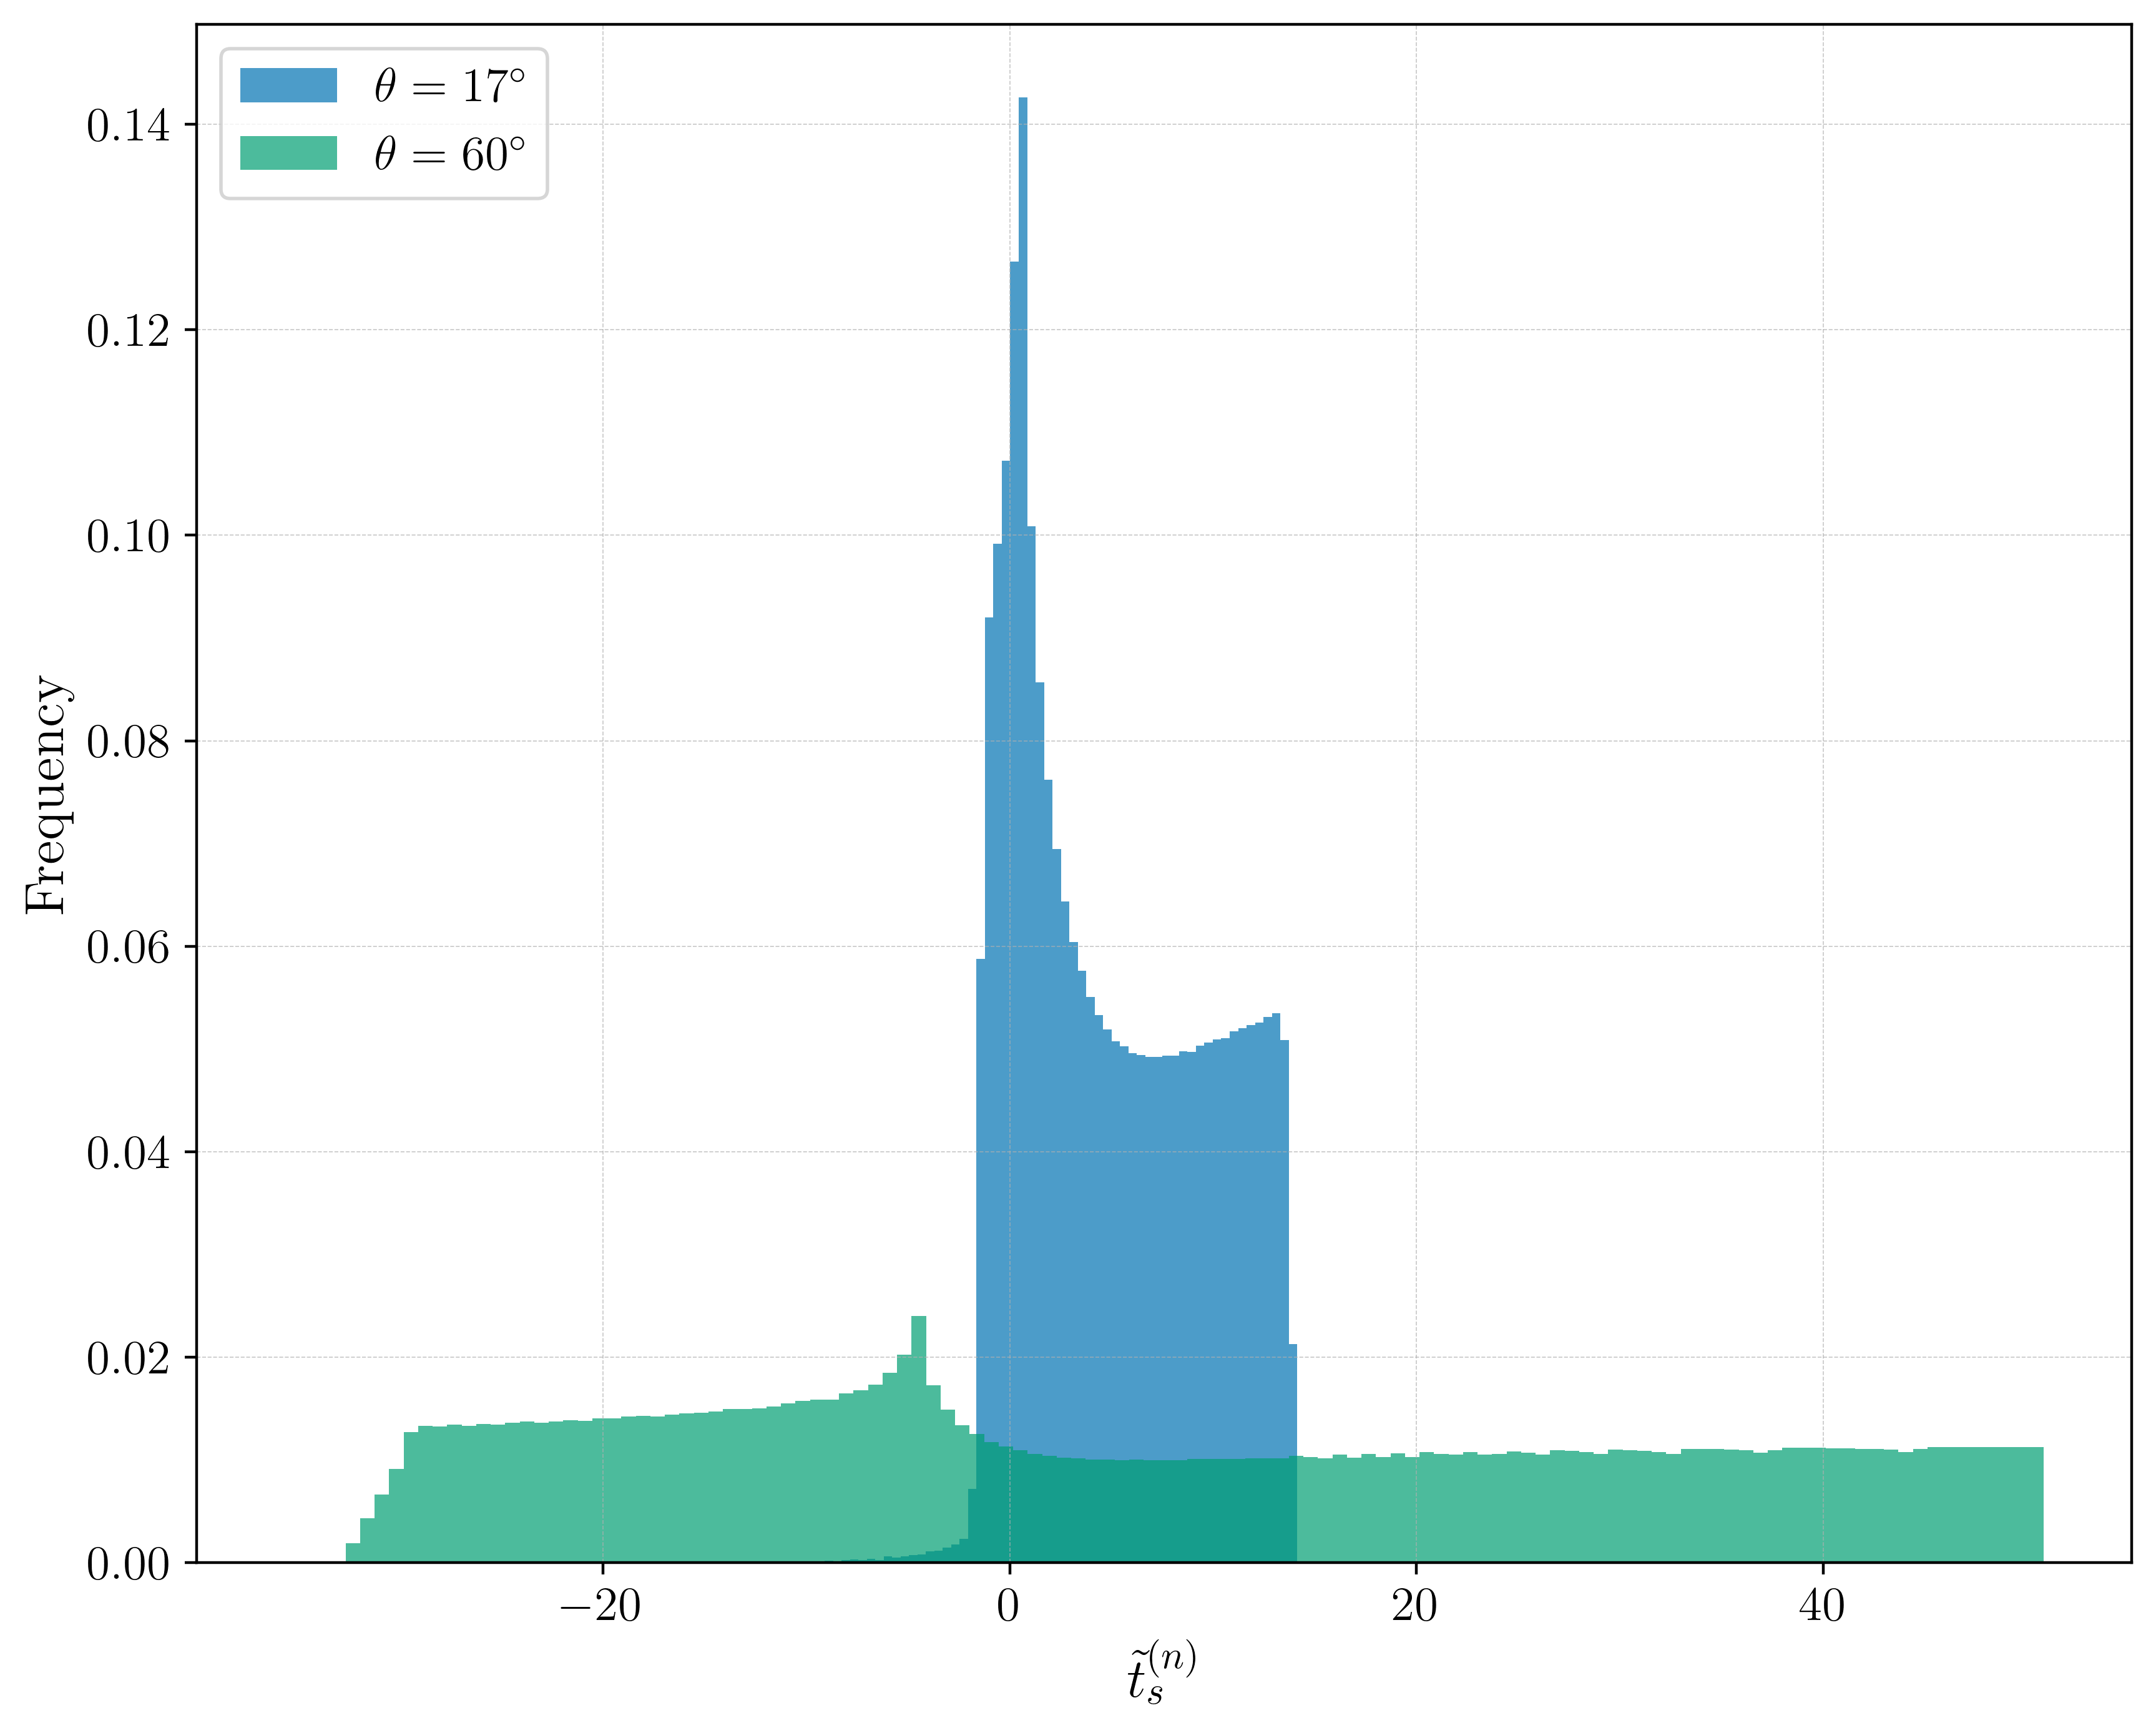

In [99]:
import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)

#peso_17 = np.ones_like(t_renorm_17) / N17_live0
#peso_60 = np.ones_like(t_renorm_60) / N60_live0

plt.hist(t_renorm_17, bins=120, color='#0072B2', label=r"$\theta = 17^{\circ}$", density=True, alpha=0.7)
plt.hist(t_renorm_60, bins=120, color='#009E73', label=r"$\theta = 60^{\circ}$", density=True, alpha=0.7)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)

#plt.savefig(path_images + rf"\HistoGrama_Norm_total.png",dpi=400,bbox_inches='tight')

plt.show()


# Histogram of $n=0,1,2$ lensing bands with  $ \theta_o = 17^\circ$

In [5]:
# Lensing bands params importation for i = 17
fnbands = path_lensingband17
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
lim0=int(h5f["lim0"][0])

supergrid1=h5f['grid1'][:]
N1=int(h5f["N1"][0])
mask1=h5f['mask1'][:]
lim1=int(h5f["lim1"][0])

supergrid2=h5f['grid2'][:]
N2=int(h5f["N2"][0])
mask2=h5f['mask2'][:]
lim2=int(h5f["lim2"][0])

h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5


In [7]:
# Ray tracing params importation for i = 17
fnrays = path_raytracing17
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

rs1=h5f['rs1'][:]
sign1=h5f['sign1'][:]
t1=h5f['t1'][:]
phi1=h5f['phi1'][:]

rs2=h5f['rs2'][:]
sign2=h5f['sign2'][:]
t2=h5f['t2'][:]
phi2=h5f['phi2'][:]

h5f.close()

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5


## $n=0$

In [59]:
#time renormalizartion 
t_renorm_0 = t0 + (D_obs + 2*np.log(D_obs))
alpha0 = supergrid0[:, 0]
beta0 = supergrid0[:, 1]

valid_mask = np.isfinite(t_renorm_0)
alpha0 = alpha0[valid_mask]
beta0 = beta0[valid_mask]
t_renorm_0 = t_renorm_0[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin0, Tmax0 = np.percentile(t_renorm_0, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_0),np.max(t_renorm_0))
print("filtered range of coordinates",Tmin0,Tmax0)

# Create a mask for the values within the range 
mask_in_range_0 = (t_renorm_0 >= Tmin0) & (t_renorm_0 <= Tmax0 )

#data filtering 
t_renorm_0 = t_renorm_0[mask_in_range_0]
alpha0 = alpha0[mask_in_range_0]
beta0 = beta0[mask_in_range_0]

# Calculate the number of bins using the Freedman-Diaconis rule
Q1 = np.percentile(t_renorm_0, 25)
Q3 = np.percentile(t_renorm_0, 75)
IQR = Q3 - Q1
rango = np.max(t_renorm_0) - np.min(t_renorm_0)

# Calcular el número de bins usando la regla de Freedman-Diaconis
N = len(t_renorm_0)
bins_freedman_diaconis0 = int(np.ceil(rango / (2 * IQR) * N**(1/3)))
bins_freedman_diaconis0
print("bins of the histogram:",bins_freedman_diaconis0)

original range of coordinates -35.667235246168275 14.249619164365868
filtered range of coordinates -35.667235246168275 14.138239200566256
bins of the histogram: 188


## $n=1$

In [61]:
#time renormalizartion 
t_renorm_1 = t1 + (D_obs + 2*np.log(D_obs))
alpha1 = supergrid1[:, 0]
beta1 = supergrid1[:, 1]

valid_mask = np.isfinite(t_renorm_1)
alpha1 = alpha1[valid_mask]
beta1 = beta1[valid_mask]
t_renorm_1 = t_renorm_1[valid_mask]

#data filtering by percentiles
minV = 5
maxV = 99.95
Tmin1, Tmax1 = np.percentile(t_renorm_1, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_1),np.max(t_renorm_1))
print("filtered range of coordinates",Tmin1,Tmax1)

# Create a mask for the values within the range 
mask_in_range_1 = (t_renorm_1 >= Tmin1) & (t_renorm_1 <= Tmax1 )

#data filtering 
t_renorm_1 = t_renorm_1[mask_in_range_1]
alpha1 = alpha1[mask_in_range_1]
beta1 = beta1[mask_in_range_1]

# Calculate the number of bins using the Freedman-Diaconis rule
rango = np.max(t_renorm_1) - np.min(t_renorm_1)
Q1 = np.percentile(t_renorm_1, 25)
Q3 = np.percentile(t_renorm_1, 75)
IQR = Q3 - Q1

N = len(t_renorm_1)
bins_freedman_diaconis1 = int(np.ceil(rango / (2 * IQR) * N**(1/3)))
print("bins of the histogram:",bins_freedman_diaconis1)

original range of coordinates -37744.01968935597 -13.562691417744645
filtered range of coordinates -132.7751268765908 -13.571262549451742
bins of the histogram: 83


## $n =2$

In [63]:
#time renormalizartion 
t_renorm_2 = t2 + (D_obs + 2*np.log(D_obs))
alpha2 = supergrid2[:, 0]
beta2 = supergrid2[:, 1]

valid_mask = np.isfinite(t_renorm_2)
alpha2 = alpha2[valid_mask]
beta2 = beta2[valid_mask]
t_renorm_2 = t_renorm_2[valid_mask]

#data filtering by percentiles
minV = 5
maxV = 99.95
Tmin2, Tmax2 = np.percentile(t_renorm_2, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_2),np.max(t_renorm_2))
print("filtered range of coordinates",Tmin2,Tmax2)

# Create a mask for the values within the range 
mask_in_range_2 = (t_renorm_2 >= Tmin2) & (t_renorm_2 <= Tmax2 )

#data filtering 
t_renorm_2 = t_renorm_2[mask_in_range_2]
alpha2 = alpha2[mask_in_range_2]
beta2 = beta2[mask_in_range_2]

# Calculate the number of bins using the Freedman-Diaconis rule
rango = np.max(t_renorm_2) - np.min(t_renorm_2)
Q1 = np.percentile(t_renorm_2, 25)
Q3 = np.percentile(t_renorm_2, 75)
IQR = Q3 - Q1

N = len(t_renorm_2)
bins_freedman_diaconis2 = int(np.ceil(rango / (2 * IQR) * N**(1/3)))
print("bins of the histogram:",bins_freedman_diaconis2)

original range of coordinates -1323.422191990705 -28.833099529940228
filtered range of coordinates -105.06475619232005 -28.83510855981303
bins of the histogram: 36


## Histograms

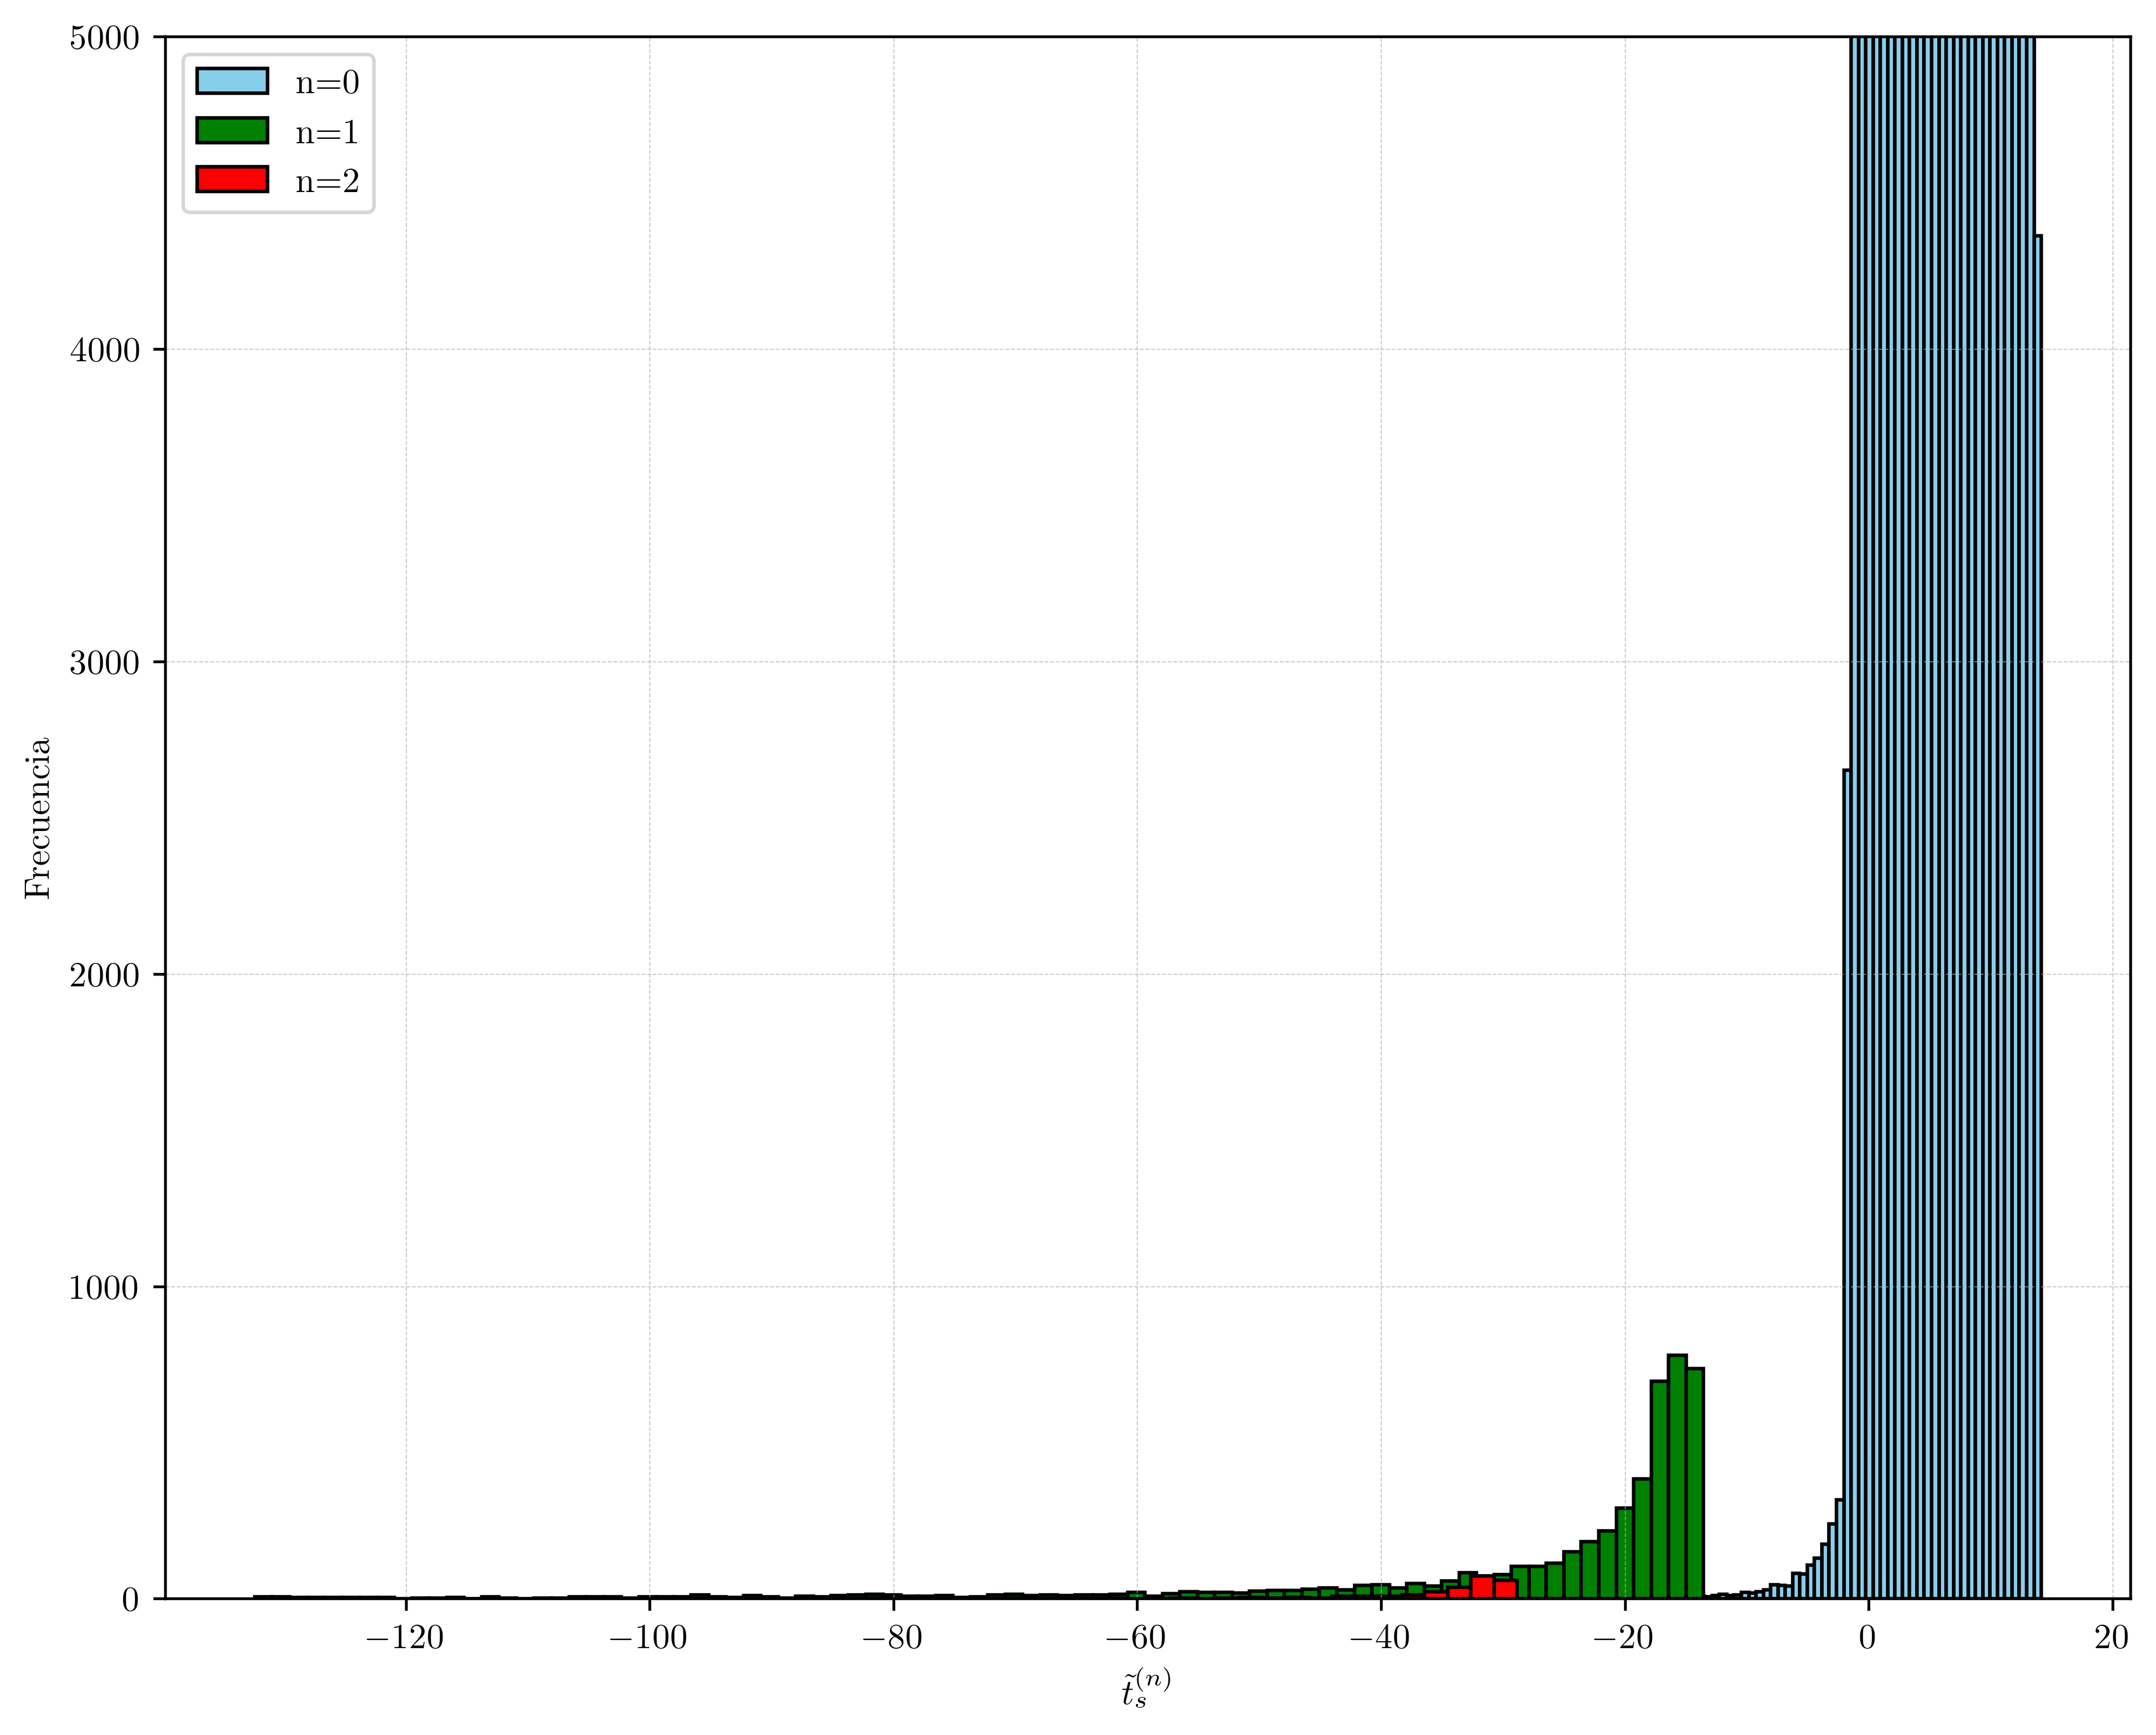

In [65]:
# Histogram without normalization

#Only if LaTeX is configured locally
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'


plt.figure(figsize=[10,8],dpi=400)
                                
plt.hist(t_renorm_0, bins=bins_freedman_diaconis1,  color='skyblue', edgecolor='black',label = "n=0")
plt.hist(t_renorm_1, bins=bins_freedman_diaconis1,  color='green', edgecolor='black',label = "n=1")
plt.hist(t_renorm_2, bins=bins_freedman_diaconis2,  color='red', edgecolor='black',label = "n=2")
plt.grid(True, linestyle='--', alpha=0.7,linewidth=0.3)

plt.ylim(0,5000)
plt.legend()
plt.xlabel(r'$\tilde{t}_s^{(n)}$')
plt.ylabel(r'$\mathrm{Frecuencia}$')

#plt.savefig(path_images + rf"\HistoGrama_i17_total.png",dpi=400,bbox_inches='tight')

plt.show()

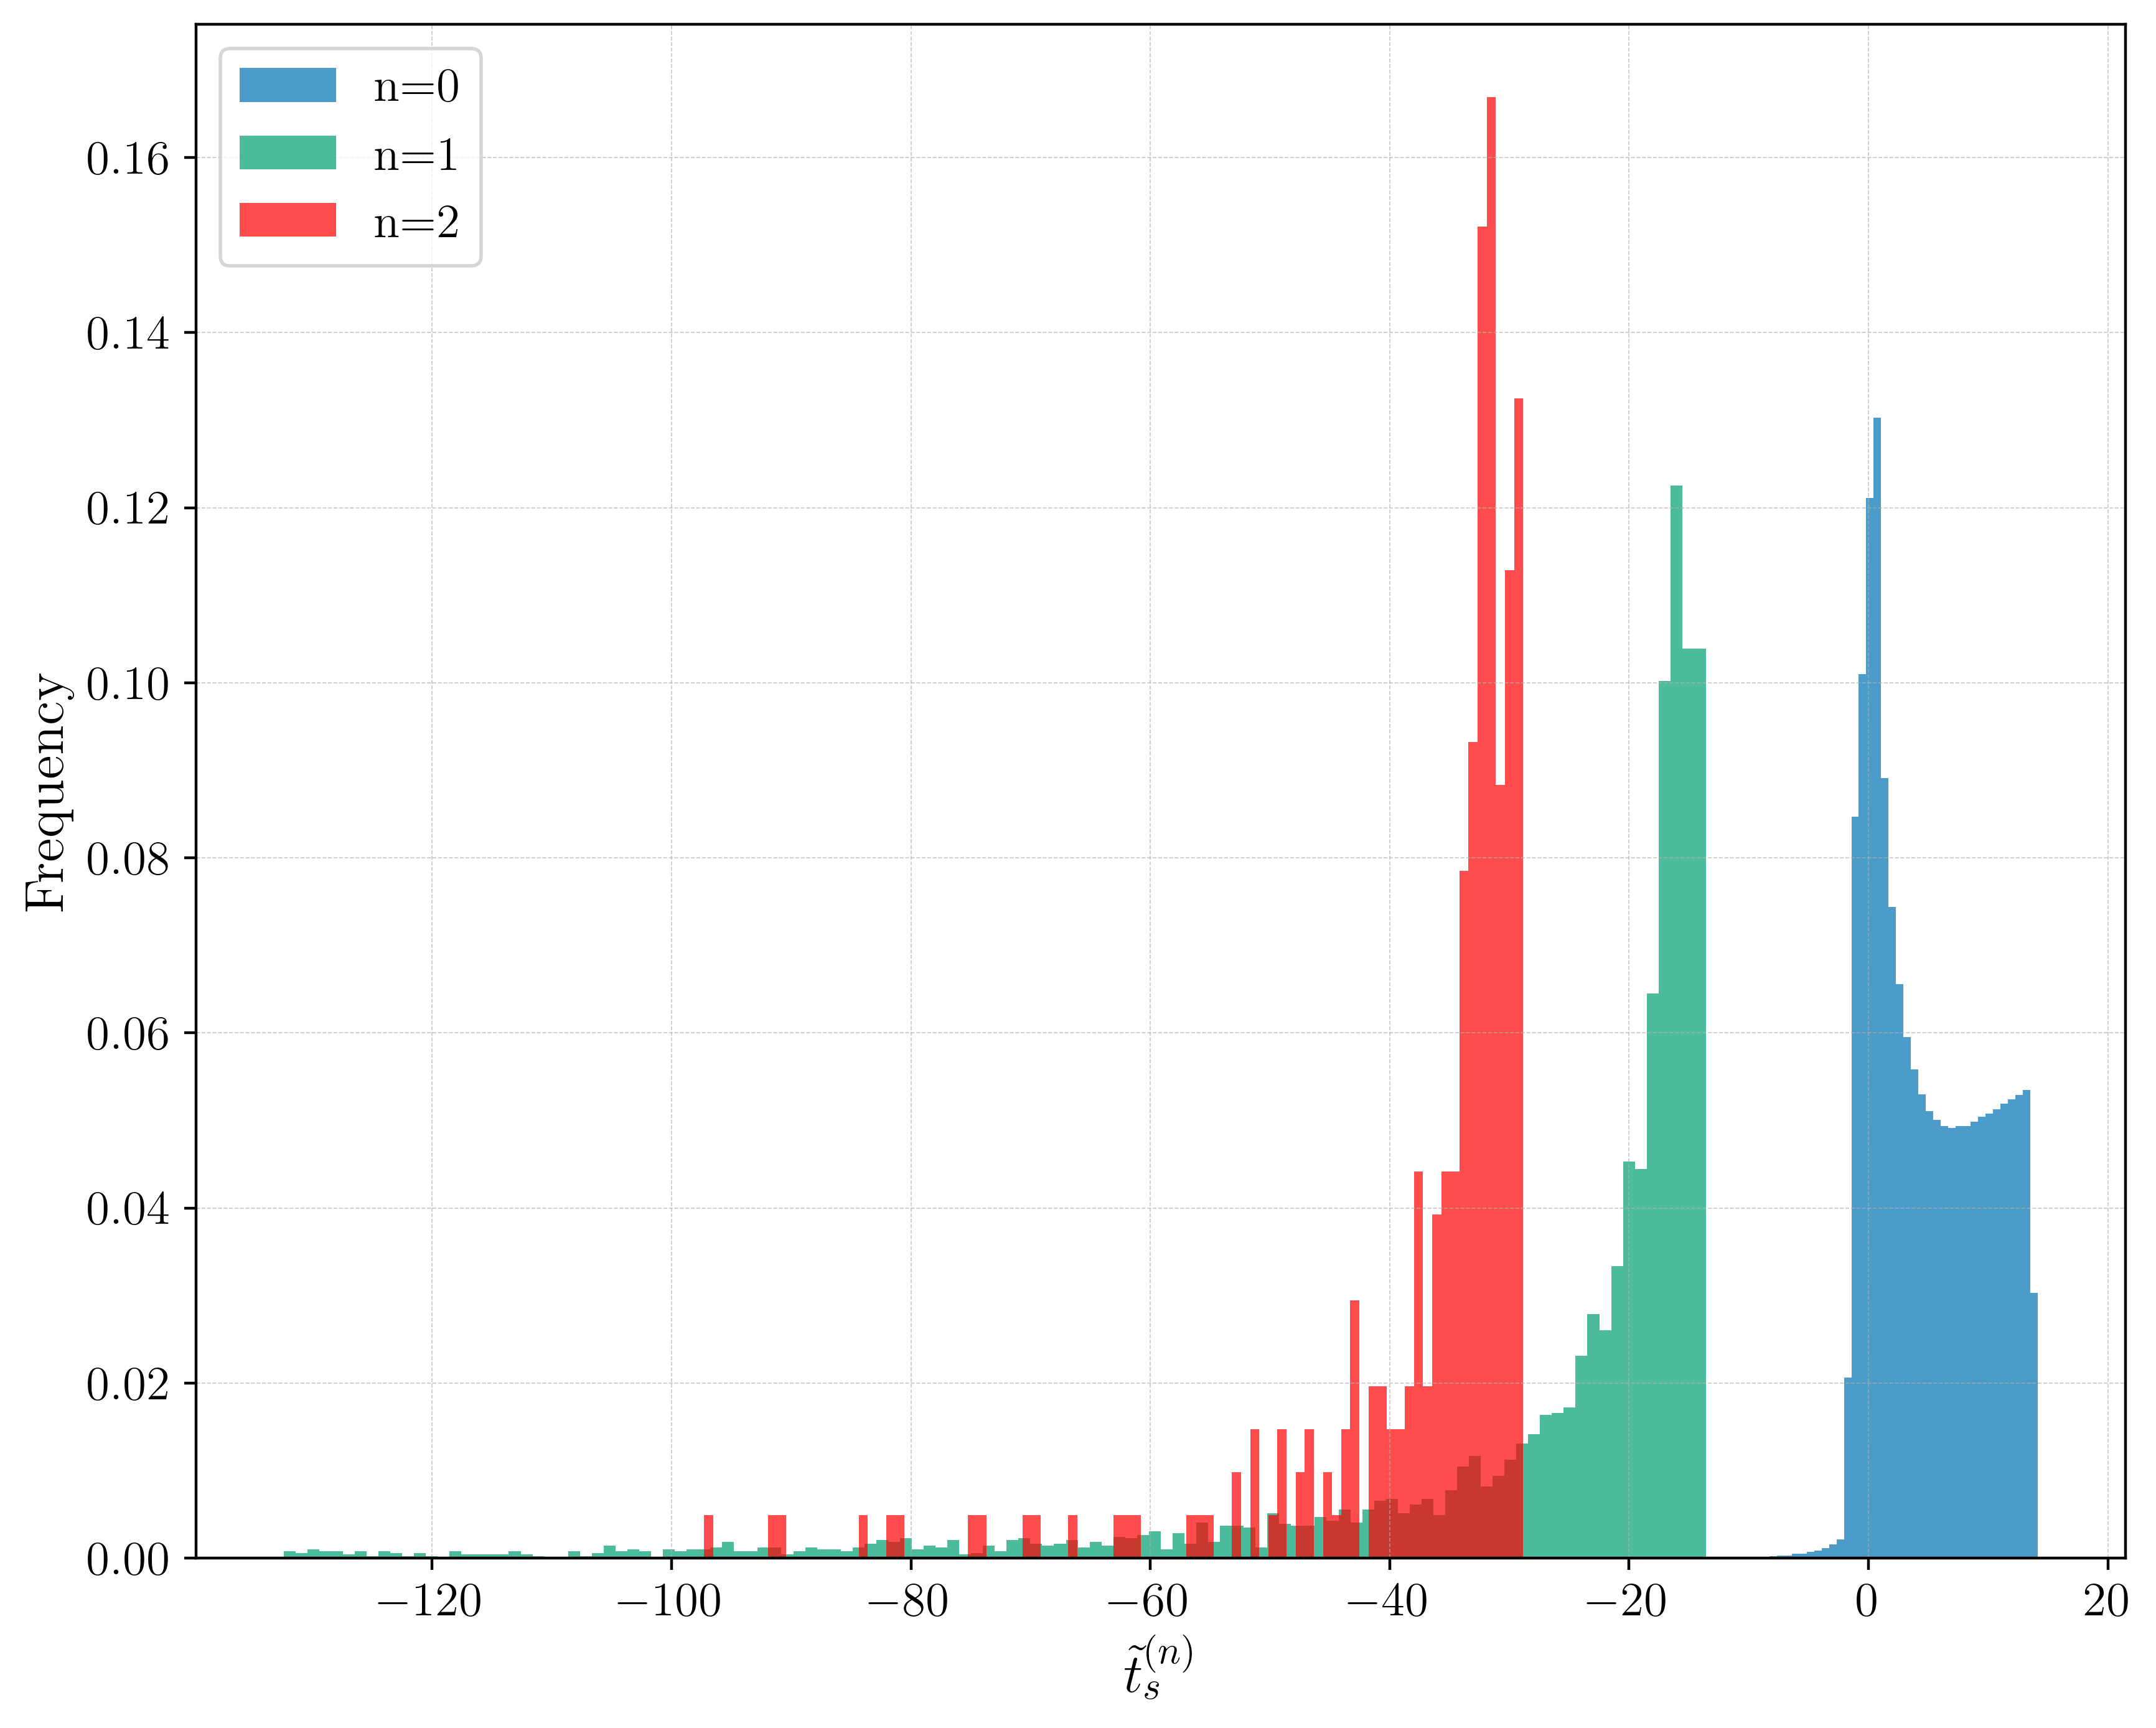

In [113]:
# Histogram with normalization based on the area of the distribution

#Only if LaTeX is configured locally
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'


plt.figure(figsize=[10,8], dpi=400)

plt.hist(t_renorm_0, bins=80, color='#0072B2', label="n=0", density=True, alpha=0.7)
plt.hist(t_renorm_1, bins=120, color='#009E73', label="n=1", density=True, alpha=0.7)
plt.hist(t_renorm_2, bins=90, color='red', label="n=2", density=True, alpha=0.7)

plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)

#plt.savefig(path_images + rf"\HistoGrama_i17_norm_total.png",dpi=400,bbox_inches='tight')

plt.show()

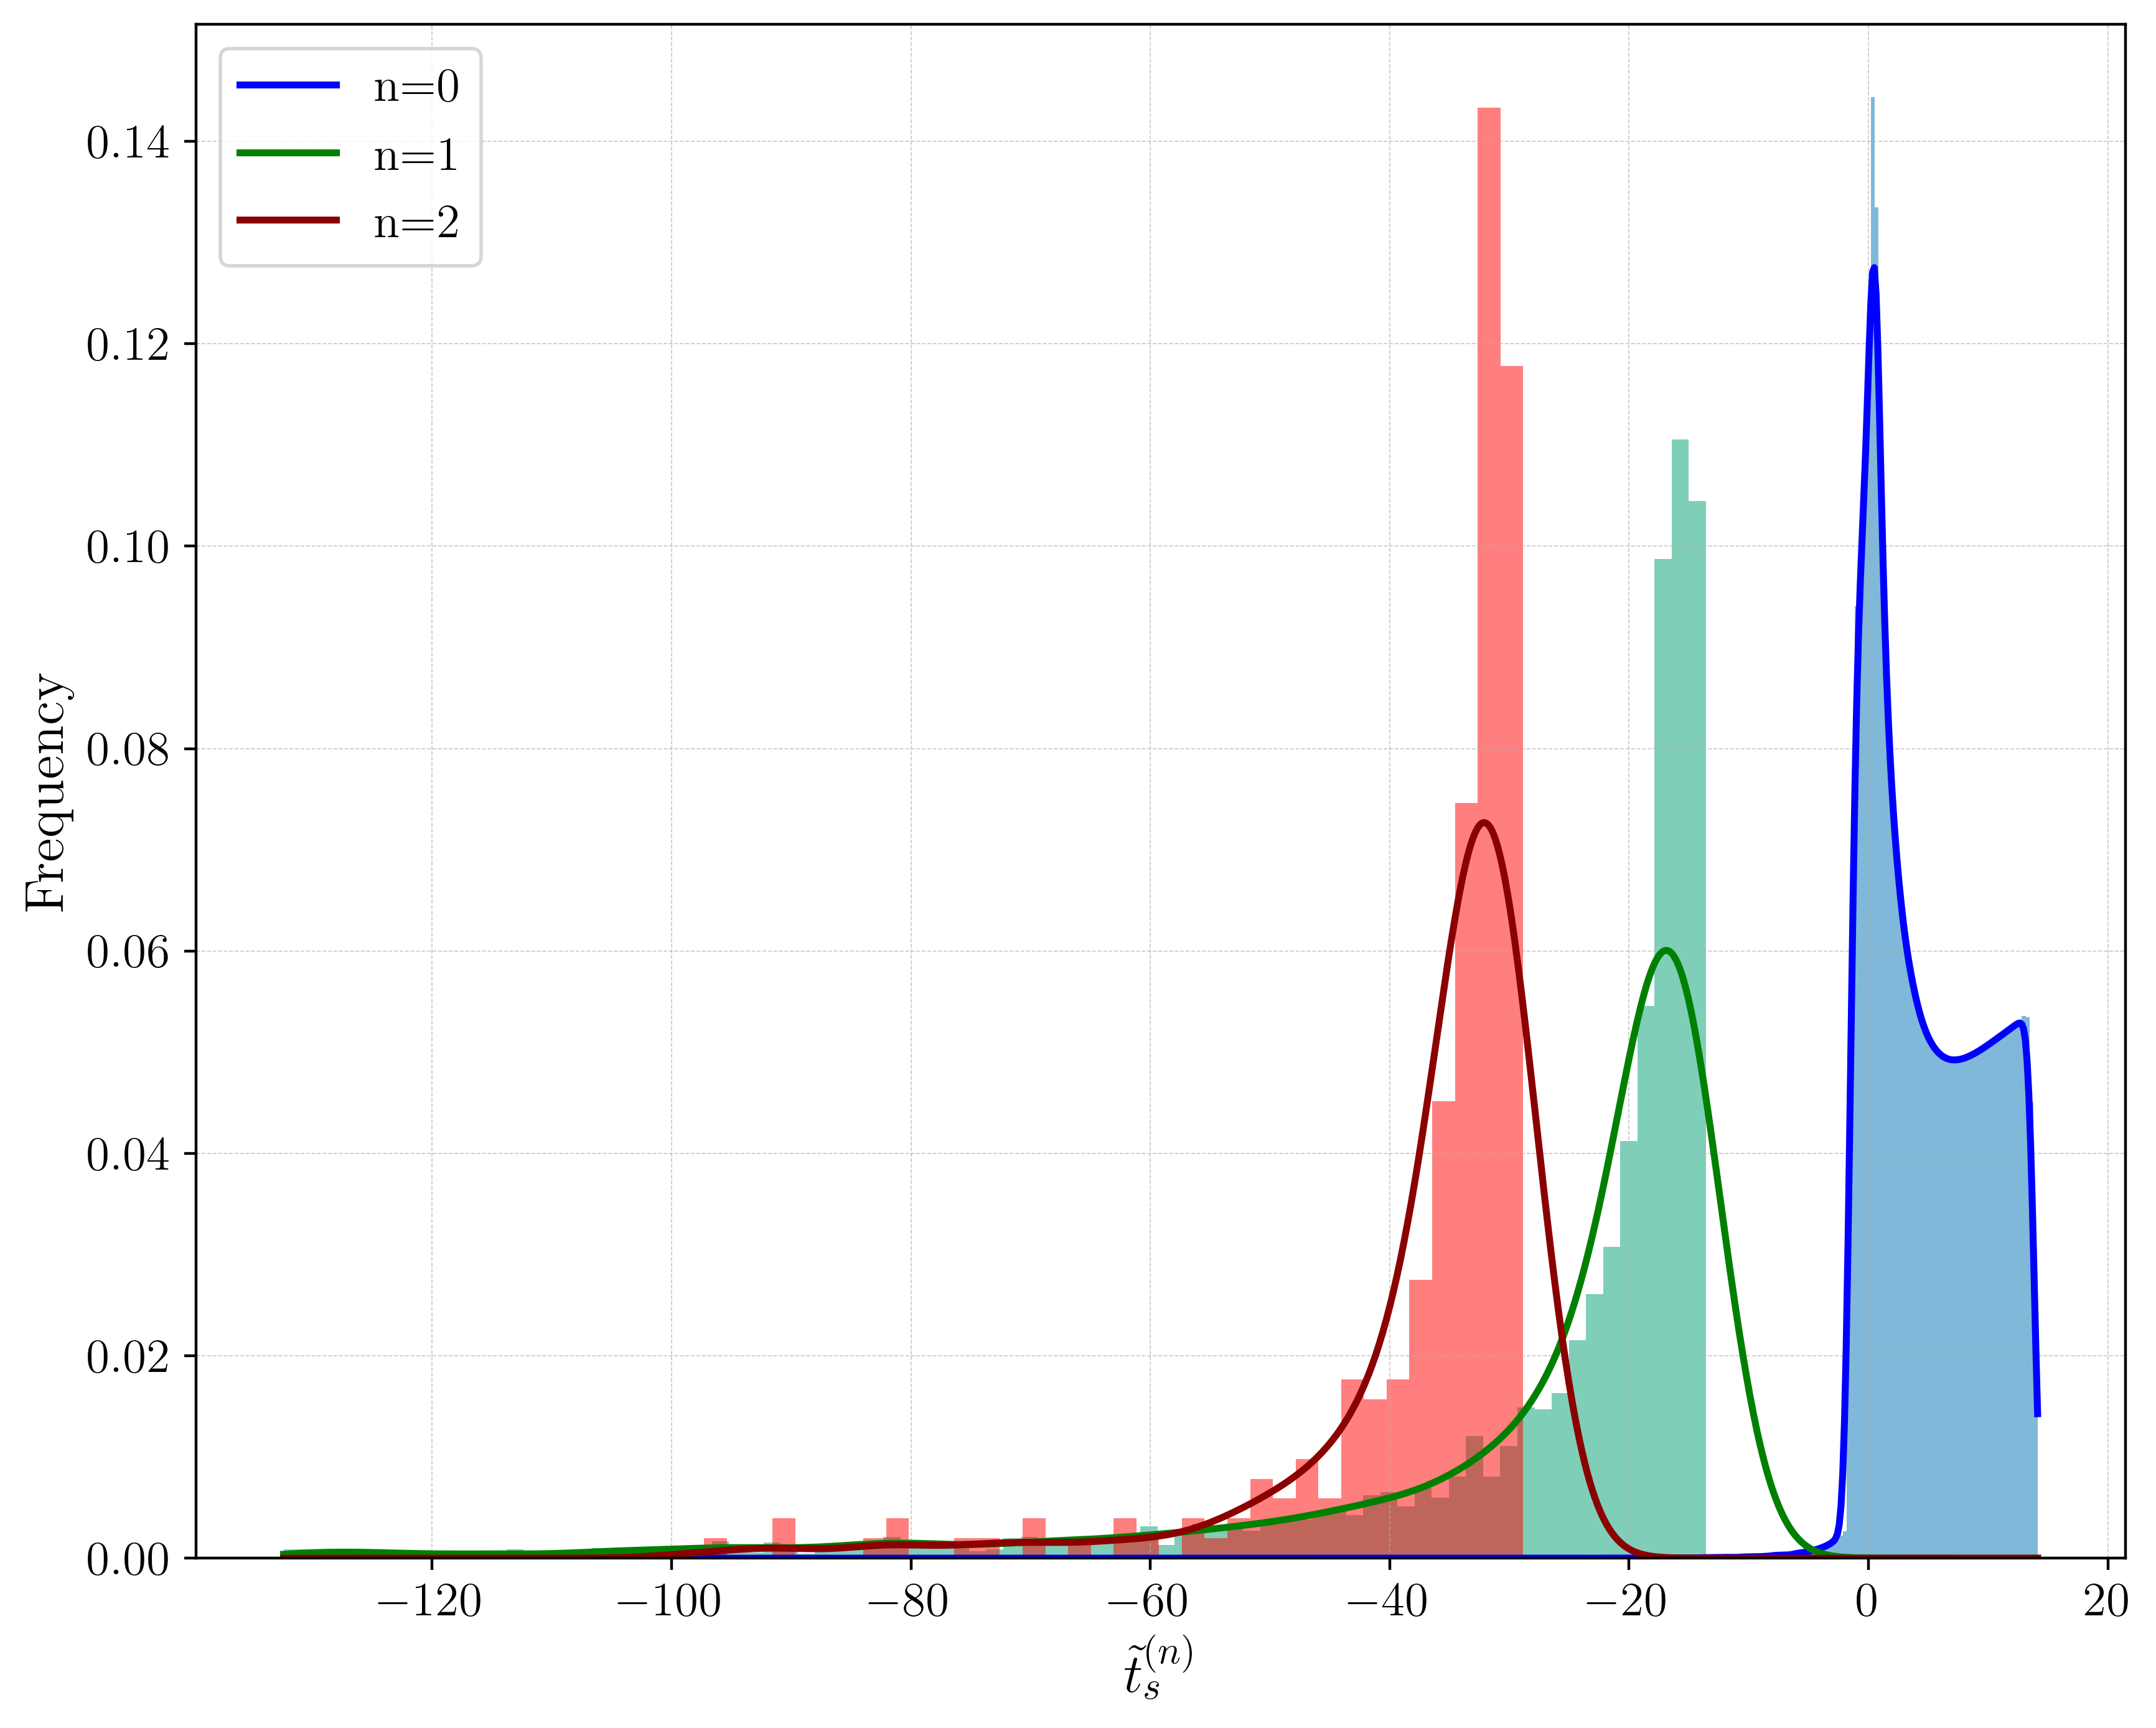

In [118]:
# Histogram with normalization based on the area of the distribution with curves distributions
from scipy.stats import gaussian_kde

# Common range
x_vals = np.linspace(min(np.min(t_renorm_0), np.min(t_renorm_1), np.min(t_renorm_2)),
                     max(np.max(t_renorm_0), np.max(t_renorm_1), np.max(t_renorm_2)),
                     1000)

# KDEs
kde0 = gaussian_kde(t_renorm_0)
kde1 = gaussian_kde(t_renorm_1)
kde2 = gaussian_kde(t_renorm_2)


plt.figure(figsize=[10,8], dpi=400)
plt.hist(t_renorm_0, bins=150, density=True, alpha=0.5,color="#0072B2")
plt.hist(t_renorm_1, bins=bins_freedman_diaconis1, density=True, alpha=0.5,color="#009E73")
plt.hist(t_renorm_2, bins=bins_freedman_diaconis2, density=True, alpha=0.5,color="red")

plt.plot(x_vals, kde0(x_vals), color="blue", lw=2, label="n=0")
plt.plot(x_vals, kde1(x_vals), color="green", lw=2, label="n=1")
plt.plot(x_vals, kde2(x_vals), color="darkred", lw=2, label="n=2")

plt.legend(loc='upper left', fontsize=14)
# Etiquetas
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

#plt.savefig(path_images + rf"HistoGrama_i17_NormCurv_total.png",dpi=400,bbox_inches='tight')
plt.show()

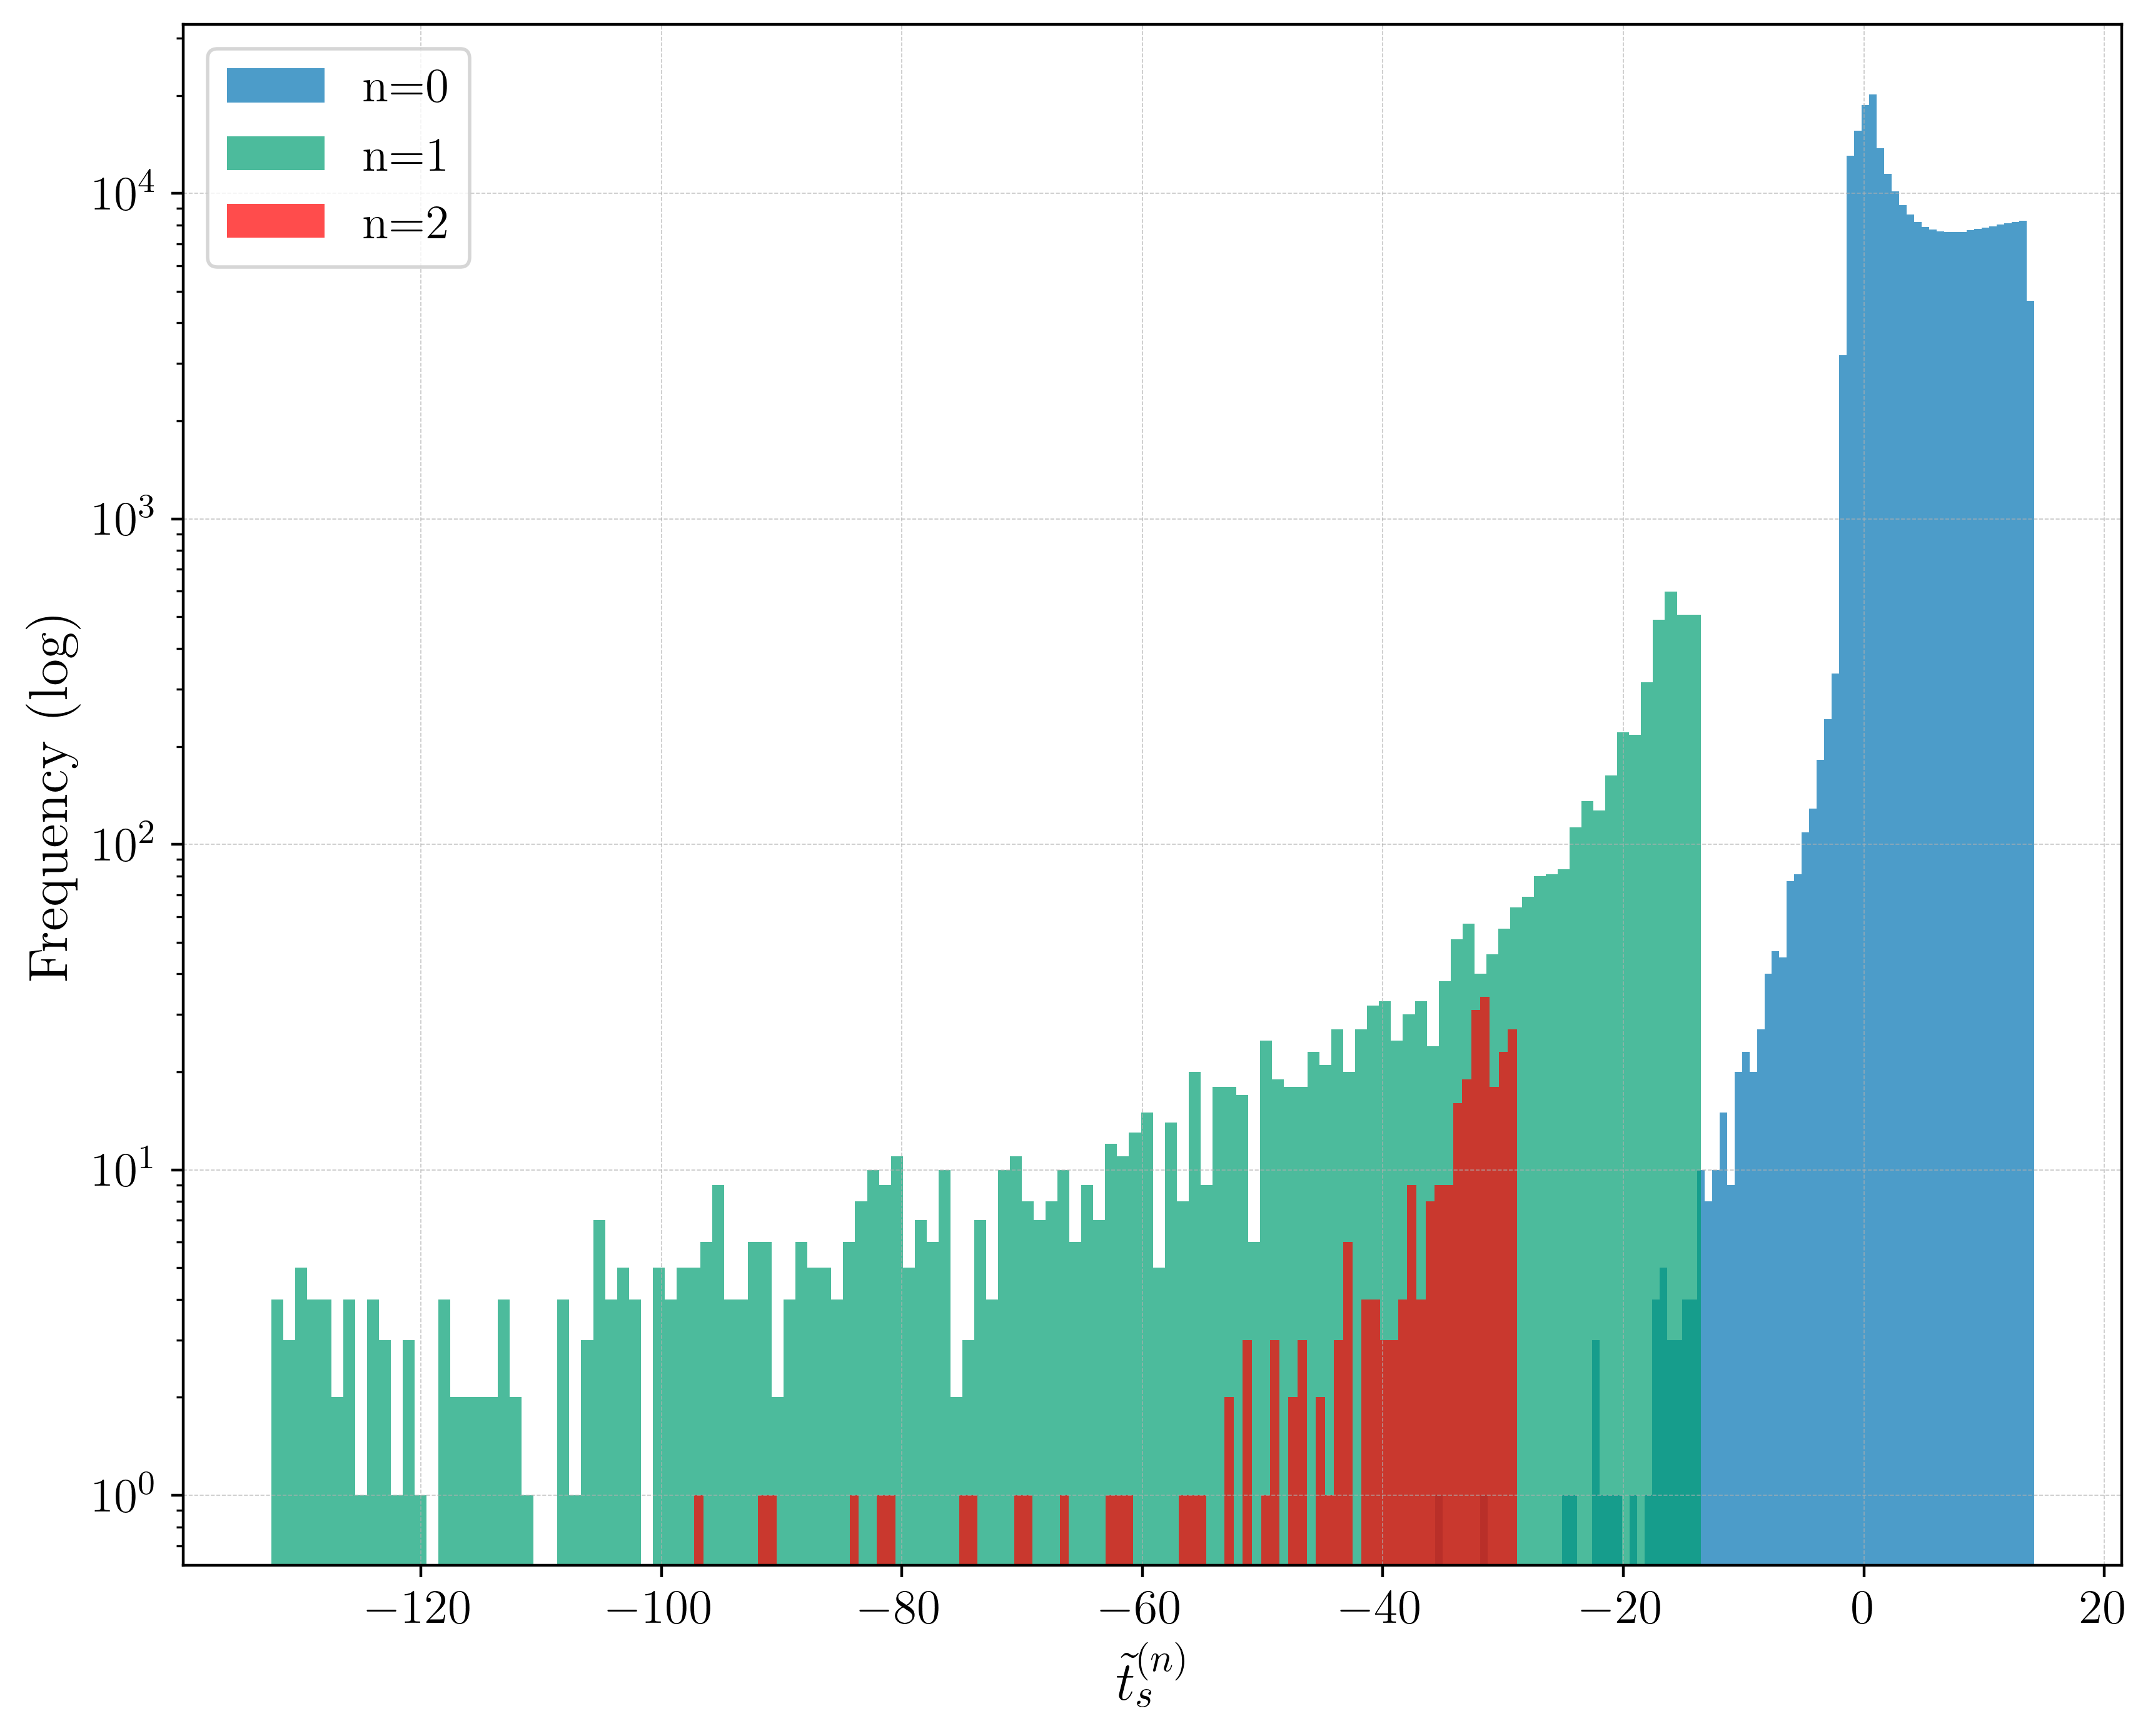

In [121]:
# Histogram with log of the frequency

#Only if LaTeX is configured locally
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Make histogram with log scale in y
plt.figure(figsize=[10,8], dpi=400)

plt.hist(t_renorm_0, bins=80, color='#0072B2', label="n=0", alpha=0.7)
plt.hist(t_renorm_1, bins=120, color='#009E73', label="n=1", alpha=0.7)
plt.hist(t_renorm_2, bins=90, color='red', label="n=2", alpha=0.7)


plt.yscale("log")  # logarithmic scale on the Y axis
plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency\ (log)}$', fontsize=16)

#plt.savefig(path_images + rf"\HistoGrama_i17_log_total.png",dpi=400,bbox_inches='tight')
plt.show()

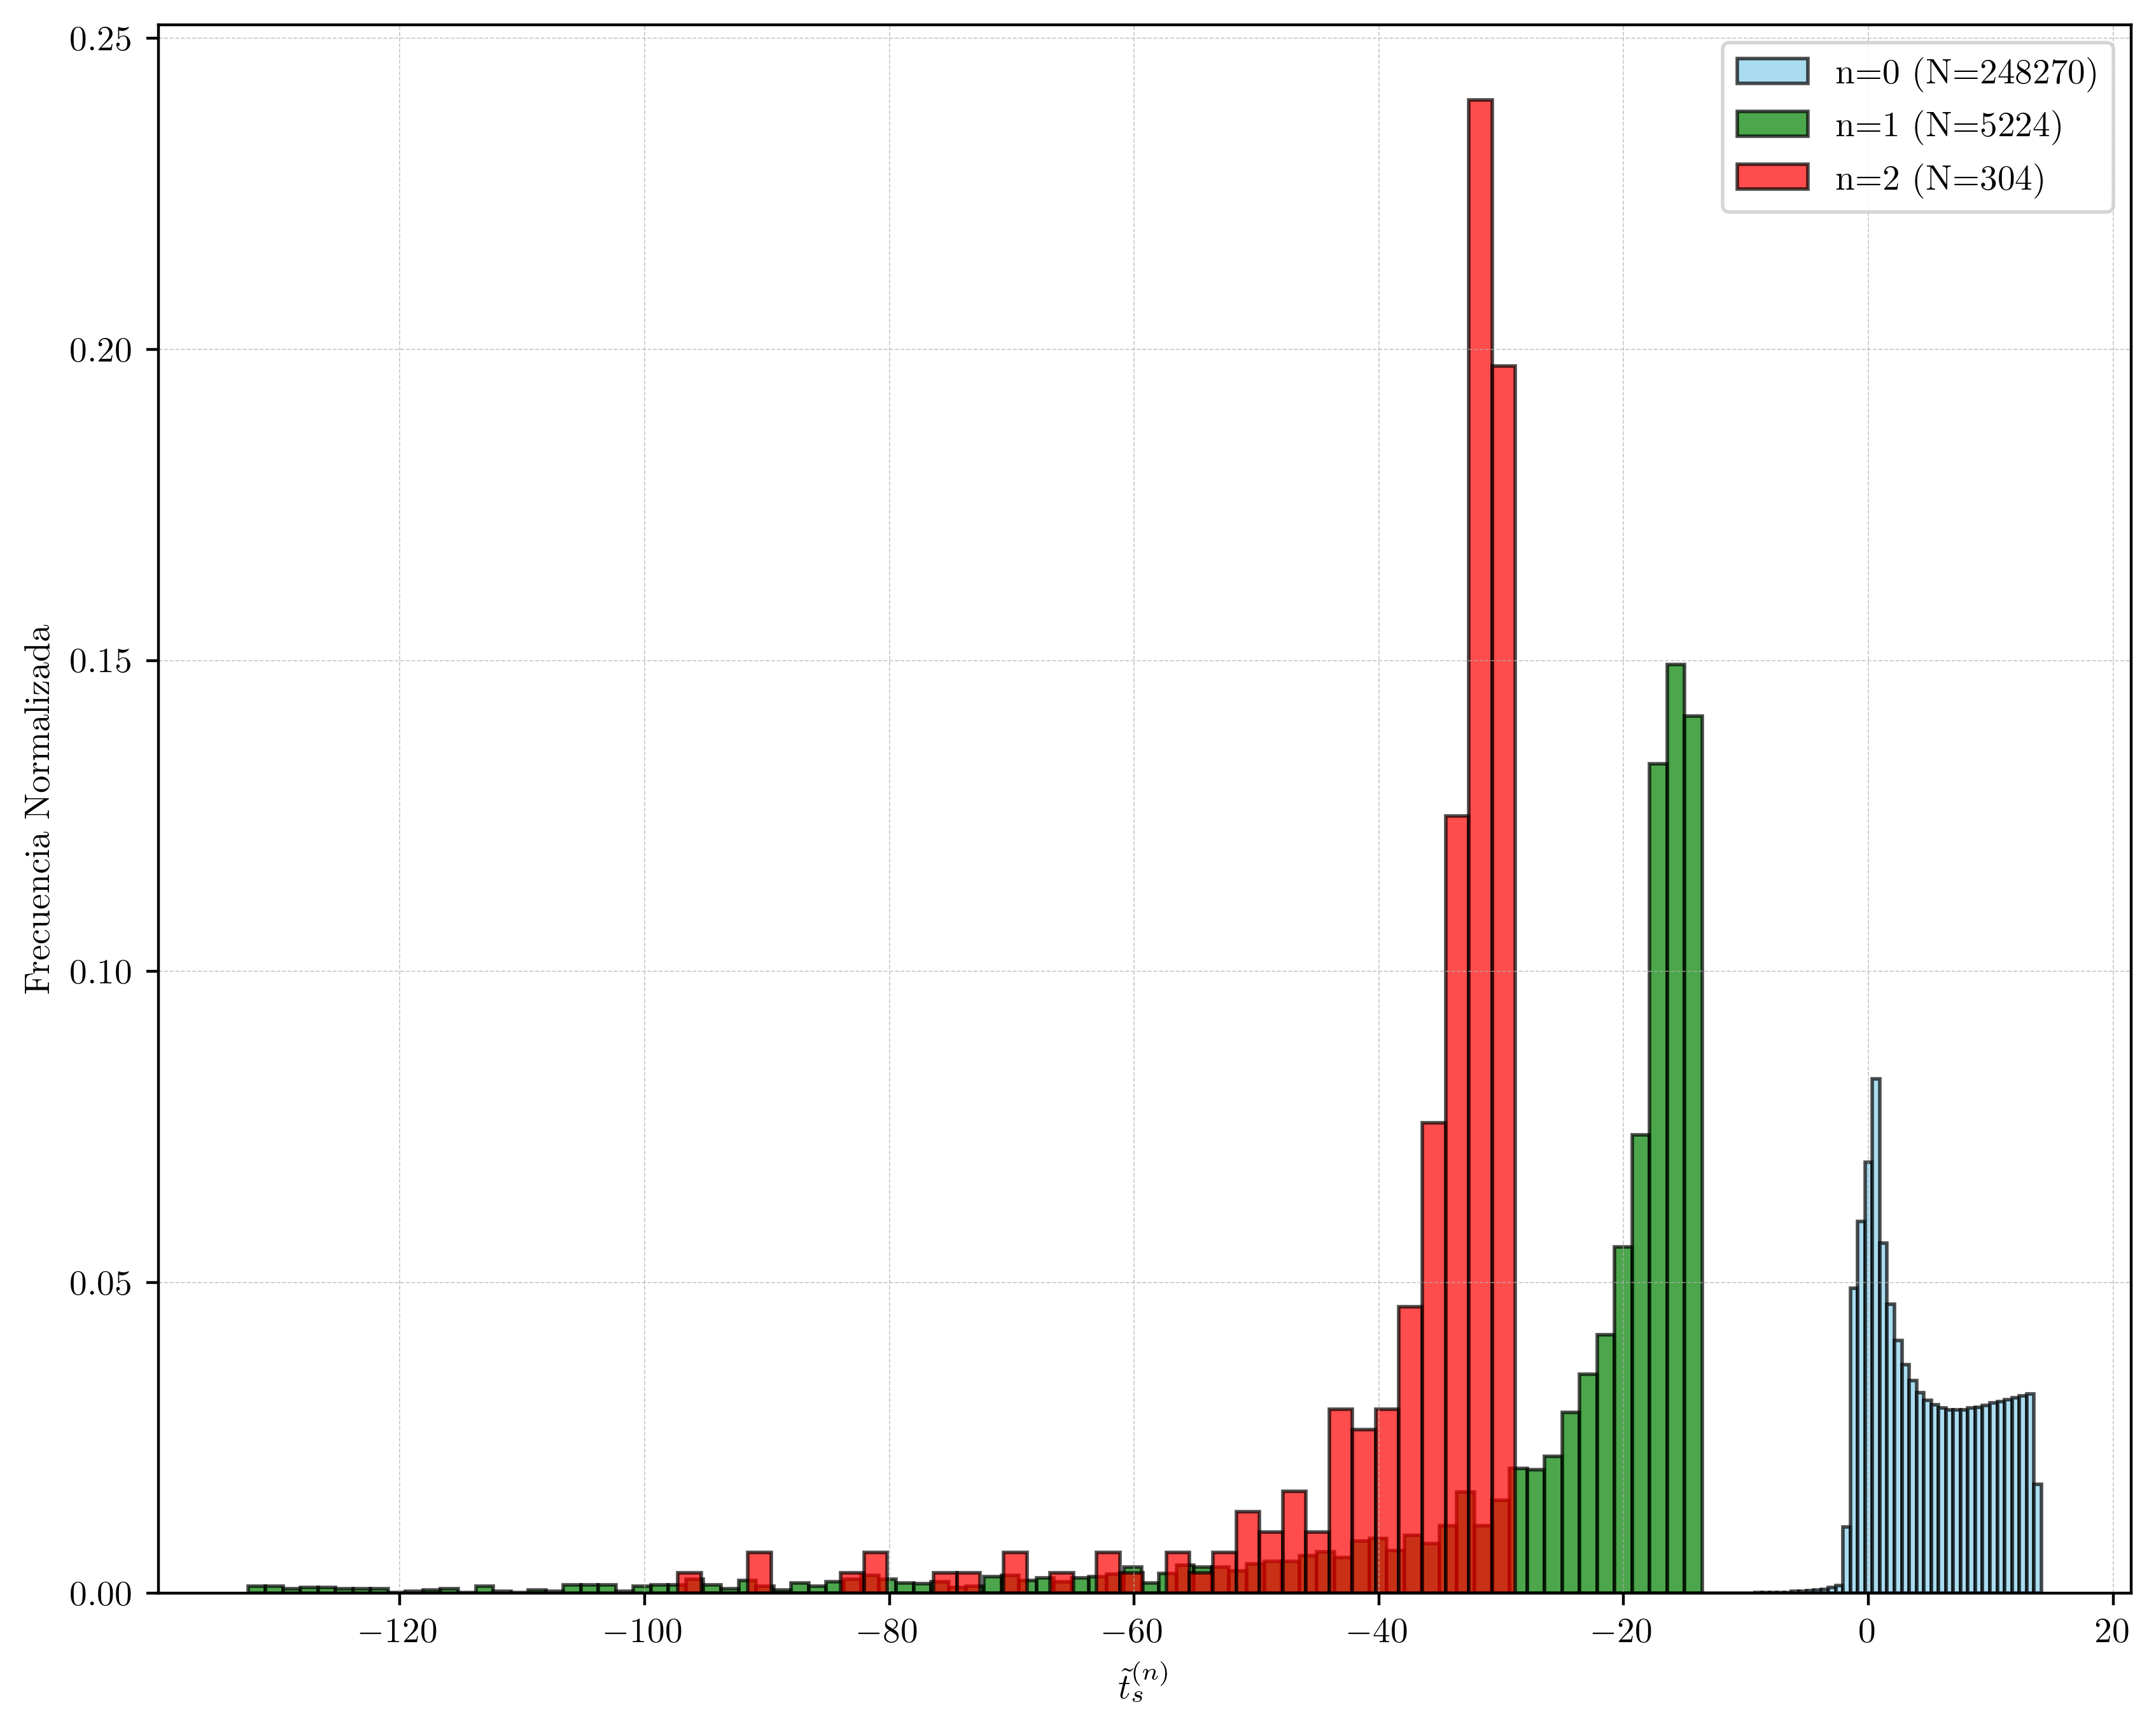

In [79]:
# Only if LaTeX is configured locally
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

plt.figure(figsize=[10,8], dpi=400)

# Calcular pesos de normalización
N_live0 = mask0.sum() 
N_live1 = mask1.sum() 
N_live2 = mask2.sum()
peso_0 = np.ones_like(t_renorm_0) / N_live0
peso_1 = np.ones_like(t_renorm_1) / N_live1  
peso_2 = np.ones_like(t_renorm_2) / N_live2

# Histogramas normalizados
plt.hist(t_renorm_0, bins=bins_freedman_diaconis1, weights=peso_0, 
         color='skyblue', edgecolor='black', label=f"n=0 (N={N_live0})", alpha=0.7)

plt.hist(t_renorm_1, bins=bins_freedman_diaconis1, weights=peso_1,
         color='green', edgecolor='black', label=f"n=1 (N={N_live1})", alpha=0.7)

plt.hist(t_renorm_2, bins=bins_freedman_diaconis2, weights=peso_2,
         color='red', edgecolor='black', label=f"n=2 (N={N_live2})", alpha=0.7)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)
plt.legend()
plt.xlabel(r'$\tilde{t}_s^{(n)}$')
plt.ylabel(r'$\mathrm{Frecuencia\ Normalizada}$')
#plt.savefig(path_images + rf"\HistoGrama_i17_total_normalized.png", dpi=400, bbox_inches='tight')
plt.show()

In [75]:
print("n=0:",len(t_renorm_0),N_live0,np.abs(len(t_renorm_0)-N_live0))
print("n=1:",len(t_renorm_1),N_live1,np.abs(len(t_renorm_1)-N_live1))
print("n=2:",len(t_renorm_2),N_live2,np.abs(len(t_renorm_2)-N_live2))

n=0: 248144 248270 126
n=1: 4929 5224 295
n=2: 268 304 36
